In [2]:
import pandas as pd

# Load market data for each symbol (example with 7 symbols)
symbols = ['2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
market_data = {}
for symbol in symbols:
    market_data[symbol] = pd.read_csv(f'{symbol}_preprocessed_data.csv')

# Load trading data (with mixed symbols)
trading_data = pd.read_parquet('merged_r8fin_trades.parquet')

In [3]:
trading_data.columns

Index(['trade_date', 'executiontime', 'brokerexecutiontime', 'exec_time_et',
       'recapid', 'orderid', 'parentcorrelationorderid', 'executionid', 'firm',
       'client', 'syntheticcontractidentifier', 'instrument',
       'syntheticpricemode', 'syntheticticksize',
       'syntheticcontractdefinition', 'security_type', 'symbol', 'cusip',
       'side', 'quantity', 'price', 'order_source', 'broker_id', 'exchange',
       'exchange_route', 'exchange_endoint', 'exchange_lp', 'is_aggressive',
       'destination', 'order_text', 'quote_or_hedge', 'hedge_target_price',
       'cash_exchange_trade_id', 'timestamp', 'build_id', 'build_name',
       'hide_duration', 'pop_ticks', 'label'],
      dtype='object')

In [4]:
trading_data['instrument']

0              Z XM ROLL 1.8% FRONTS
1              Z XM ROLL 1.8% FRONTS
2              Z XM ROLL 1.8% FRONTS
3              Z XM ROLL 1.8% FRONTS
4              Z XM ROLL 1.8% FRONTS
                     ...            
5923554    CT5-TYZ4-CT10 (TYFLY) (Y)
5923555    CT5-TYZ4-CT10 (TYFLY) (Y)
5923556    CT5-TYZ4-CT10 (TYFLY) (Y)
5923557    CT5-TYZ4-CT10 (TYFLY) (Y)
5923558                 CT2-CT30 (Y)
Name: instrument, Length: 5923559, dtype: object

In [5]:
trading_data['is_aggressive'].unique()

array([nan,  0.,  1.])

In [6]:
trading_data['side'].unique()

array(['B', 'S'], dtype=object)

In [7]:
trading_data['symbol'].unique()

array(['SFE XMU4-XMZ4', 'SFE XMZ4', 'SFE YMZ4', 'SFE YMU4-YMZ4',
       'CBOT TYZ4', 'CBOT WNZ4', 'CBOT TUZ4', 'CME SFRZ5', 'CBOT FFV4',
       'EUREX UBZ4', 'EUREX OEZ4', 'CBOT FFN5-FFQ5', 'EUREX DUZ4',
       'IFLL ERZ4', 'ME CVZ4', 'ME CNZ4', 'ME CORH5', 'ME CORZ4',
       'ME CORZ5', 'ME CORU5', 'ME CORH6', 'ME CORM5', 'ME XQZ4',
       'CME SFRH5', 'CME SERV4-FFV4', 'CBOT FFX4', 'CBOT FFU4',
       'CBOT USZ4', 'CBOT UXYZ4', 'CBOT FVZ4', 'ME CORM6',
       'CME SFR:AB 02Y Z4', 'CME SFRZ4', 'CME SERU4', 'EUREX IKZ4',
       'EUREX RXZ4', 'CME SERV4', 'CME SERX4', 'IFLL ERU5', 'EUREX OATZ4',
       'EUREX BTSZ4', 'CME SFR:BF M6-U6-Z6', 'CME SERF5-FFF5',
       'CME SFRZ4-SFRZ5', 'CME SFR:AB 01Y Z4', 'CME SFR:AB 01Y Z7',
       'CME SFR:AB 01Y Z6', 'CME SFR:AB 01Y Z5', 'CME SFRU4', 'CME SFRZ8',
       'CME SFRH9', 'CME SFRM9', 'CME SFR:AB 05Y Z4', 'CME SFR:AB 03Y Z4',
       'CME SFRM5', 'CME SFRU5', 'CME SFRU6', 'CME SFRM6', 'IFLL G Z4',
       'CME SFRH8', 'CME SFRZ6', 'CME SFRH6',

# how many trades for each symbol

In [9]:
# Count the number of trades for each symbol
symbol_trade_counts = trading_data['symbol'].value_counts()
print(symbol_trade_counts.head(40))

symbol
5 Year                 535599
10 Year                387564
CME SFR:AB 03Y Z4      292452
CME SFR:AB 03Y U4      270612
2 Year                 252525
3 Year                 215598
CME SFR:AB 02Y U4      208608
CME SFR:AB 02Y Z4      201048
30 Year                177066
7 Year                 173103
CBOT TUZ4              162625
CBOT FVZ4              157161
CME SFR:AB 05Y Z4      154860
CBOT TYZ4              125117
CME SFR:AB 05Y U4      118780
CBOT UXYZ4              92436
EUREX RXZ4              83367
20 Year                 76921
CBOT WNZ4               75073
CBOT FVU4               70188
CBOT TUU4               70158
CME SFR:AB 01Y Z4       68044
CBOT USZ4               58088
CME SFR:AB 01Y U4       57790
CME SFR:AB 01Y U5       53626
CBOT TYU4               53218
CME SFR:AB 01Y Z5       48488
EUREX DUZ4              47386
IFLL SFI: BNDLY2 U4     44904
EUREX OEZ4              36107
CBOT UXYU4              33791
CBOT WNU4               31958
CME SFRZ5               31284
CME

In [10]:
specific_symbols = ['20 Year O1', '10 Year O1', '30 Year O1', '7 Year O1', '5 Year O1', '3 Year O1', '7 Year O2']

# Get the trade counts for the specific symbols
specific_symbol_counts = symbol_trade_counts[symbol_trade_counts.index.isin(specific_symbols)]
print(specific_symbol_counts)

symbol
10 Year O1    1209
5 Year O1      340
7 Year O1      238
20 Year O1     112
3 Year O1       34
30 Year O1      16
7 Year O2        2
Name: count, dtype: int64


# look the difference between '10 Year'and '10 Year O1'

In [12]:
trading_data['quote_or_hedge'].unique()

array(['Other', 'Hedge', 'Quote'], dtype=object)

In [13]:
trading_data['quantity']

0          171.0
1          171.0
2           65.0
3           65.0
4            4.0
           ...  
5923554      1.0
5923555      1.0
5923556      3.0
5923557      1.0
5923558      1.0
Name: quantity, Length: 5923559, dtype: float64

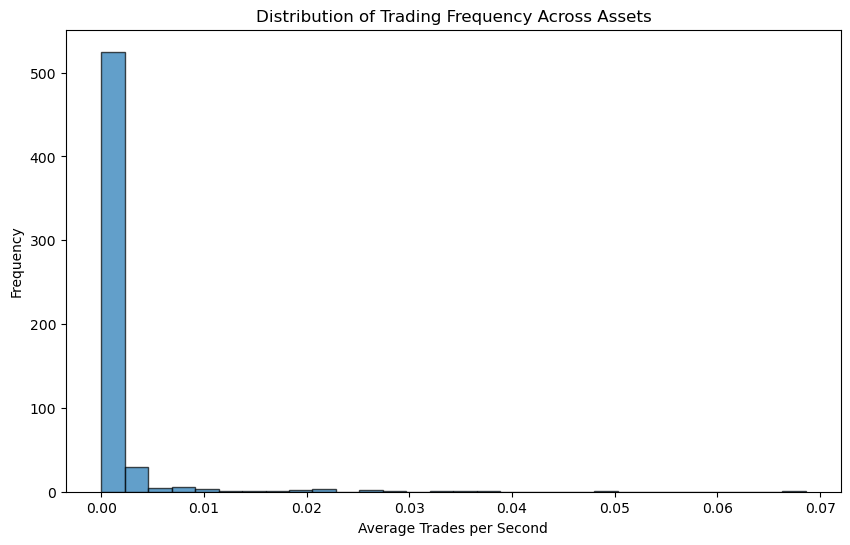

count    5.850000e+02
mean     1.296745e-03
std      5.254958e-03
min      1.280642e-07
25%      6.915468e-06
50%      3.739475e-05
75%      3.310460e-04
max      6.859107e-02
dtype: float64


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

trading_data['timestamp'] = pd.to_datetime(trading_data['timestamp'])


trading_data['time_diff'] = trading_data['timestamp'].diff().dt.total_seconds()

# Calculate the number of trades per second

# The frequency of trades per second for each asset can be calculated by dividing the number of trades by the total duration in seconds
frequency = trading_data.groupby('symbol').size() / (trading_data['timestamp'].max() - trading_data['timestamp'].min()).total_seconds()


plt.figure(figsize=(10, 6))
plt.hist(frequency, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Average Trades per Second')
plt.ylabel('Frequency')
plt.title('Distribution of Trading Frequency Across Assets')
plt.show()

print(frequency.describe())

In [15]:
# Calculate the total number of trades per symbol
total_trades = trading_data.groupby('symbol').size()

# Calculate the total market hours (assuming the market opens at 9:30 AM and closes at 4:00 PM)
market_start_time = pd.to_datetime('09:30:00')
market_end_time = pd.to_datetime('16:00:00')
market_duration_seconds = (market_end_time - market_start_time).seconds

min_bin_size_seconds = market_duration_seconds / (total_trades / 20)  # Bin size ensuring at least 10 trades

# Check for the minimum bin size that ensures 10-20 trades
min_bin_size_seconds

symbol
10 Year             1.207542
10 Year O1        387.096774
2 Year              1.853282
20 Year             6.084164
20 Year O1       4178.571429
                    ...     
SFE YMU4-YMZ4    1368.421053
SFE YMU4XMU4     1779.467681
SFE YMZ4         3162.162162
SFE YMZ4XMZ4     1966.386555
SGX XUV4         3744.000000
Length: 585, dtype: float64

In [16]:
min_bin_size_seconds.head(20)

symbol
10 Year                     1.207542
10 Year O1                387.096774
2 Year                      1.853282
20 Year                     6.084164
20 Year O1               4178.571429
3 Year                      2.170707
3 Year O1               13764.705882
30 Year                     2.643082
30 Year O1              29250.000000
5 Year                      0.873788
5 Year O1                1376.470588
7 Year                      2.703593
7 Year O1                1966.386555
7 Year O2              234000.000000
CBOT 3YU4                 116.679132
CBOT 3YU4-3YZ4         234000.000000
CBOT 3YZ4                 102.609077
CBOT FF:BF K5-N5-Q5    156000.000000
CBOT FF:BF U4-V4-X4    234000.000000
CBOT FF:BF V4-X4-F5      3416.058394
dtype: float64

In [17]:
for symbol in symbols:
    market_data[symbol]['time'] = market_data[symbol]['time_bin'].str.extract(r'\(([^,]+),')

In [18]:
market_data

{'2Y':                                           time_bin  cumulative_size  \
 0       (2024-07-31 23:59:50, 2024-08-01 00:00:00]             3742   
 1       (2024-08-01 09:30:00, 2024-08-01 09:30:10]            79336   
 2       (2024-08-01 09:30:10, 2024-08-01 09:30:20]            80370   
 3       (2024-08-01 09:30:20, 2024-08-01 09:30:30]            39697   
 4       (2024-08-01 09:30:30, 2024-08-01 09:30:40]            20526   
 ...                                            ...              ...   
 215367  (2024-10-31 15:59:10, 2024-10-31 15:59:20]           380428   
 215368  (2024-10-31 15:59:20, 2024-10-31 15:59:30]           335117   
 215369  (2024-10-31 15:59:30, 2024-10-31 15:59:40]           329124   
 215370  (2024-10-31 15:59:40, 2024-10-31 15:59:50]           506492   
 215371  (2024-10-31 15:59:50, 2024-10-31 16:00:00]           575829   
 
              price  signed_size                 time  
 0       100.181641        -2102  2024-07-31 23:59:50  
 1       100.232

In [19]:
def calculate_metrics_with_bin(market_data, bin_size):
    """
    Calculate price variation, net order flow, price variation volatility, and signed order flow volatility.

    Parameters:
        market_data (dict): Dictionary where keys are symbols and values are DataFrames with columns ['time', 'bid_size', 'bid_price', 'ask_size', 'ask_price'].
        bin_size (int): Bin size in seconds (e.g., 10, 20, 30, etc.).

    Returns:
        dict: A dictionary of DataFrames with aggregated metrics for each symbol.
    """
    results = {}
    for symbol, data in market_data.items():
        # Ensure time is in datetime format
        data['time'] = pd.to_datetime(data['time'])


        # Extract date for grouping
        data['date'] = data['time'].dt.date

        # Create shifted mid-price for price variation
        shift_steps = bin_size // 10  # Number of rows to shift (bin_size in multiples of 10 seconds)
        data['shifted_price'] = data['price'].shift(-shift_steps)
        data['price_variation'] = data['shifted_price'] - data['price']

        # Calculate net order flow within each rolling window
        data['order_flow'] = data['signed_size'].rolling(shift_steps, min_periods=1).sum()

        # Group by date to calculate daily volatility
        daily_metrics = data.groupby('date').agg(
            price_variation_volatility=('price_variation', lambda x: np.sqrt(np.mean(x**2))),
            order_flow_volatility=('order_flow', lambda x: np.sqrt(np.mean(x**2)))
        ).reset_index()

        # Merge daily volatility back to the original data
        data = pd.merge(data, daily_metrics, on='date', how='left')

        # Keep relevant columns
        results[symbol] = data[['time','price_variation', 'order_flow', 'price_variation_volatility', 'order_flow_volatility']]

    return results

In [20]:
import numpy as np
calculate_metrics_with_bin(market_data, 10)['10Y'].head(10)

,time,price_variation,order_flow,price_variation_volatility,order_flow_volatility
0,2024-07-31 23:59:50,0.302734,569.0,0.302734,569.000000
1,2024-08-01 09:30:00,-0.023438,9735.0,0.022235,5200.035787
2,2024-08-01 09:30:10,0.011719,10074.0,0.022235,5200.035787
3,2024-08-01 09:30:20,-0.005859,1077.0,0.022235,5200.035787
4,2024-08-01 09:30:30,0.000000,869.0,0.022235,5200.035787
5,2024-08-01 09:30:40,0.011719,127.0,0.022235,5200.035787
6,2024-08-01 09:30:50,-0.013672,2201.0,0.022235,5200.035787
7,2024-08-01 09:31:00,0.005859,529.0,0.022235,5200.035787
8,2024-08-01 09:31:10,0.023438,5947.0,0.022235,5200.035787
9,2024-08-01 09:31:20,-0.003906,2488.0,0.022235,5200.035787


In [21]:
import pandas as pd

trading_data['timestamp'] = pd.to_datetime(trading_data['timestamp'])

# 'B' for Buy, 'S' for Sell
trading_data['order_flow'] = trading_data['side'].map({'B': 1, 'S': -1}) * trading_data['quantity']

# Round the timestamp to the nearest 10 seconds for grouping
trading_data['time_rounded'] = trading_data['timestamp'].dt.floor('10S')

# Group by the rounded timestamp and sum the order flows for each 10-second interval
order_flow_aggregated = trading_data.groupby('time_rounded')['order_flow'].sum().reset_index()

/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_1938/185544999.py:9: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  trading_data['time_rounded'] = trading_data['timestamp'].dt.floor('10S')


In [22]:
order_flow_aggregated

,time_rounded,order_flow
0,2024-08-02 11:56:30,-17.0
1,2024-08-02 12:03:00,-51.0
2,2024-08-02 12:03:30,-81.0
3,2024-08-02 12:03:40,-23.0
4,2024-08-02 12:33:40,15.0
...,...,...
229171,2024-10-31 20:59:00,-11.0
229172,2024-10-31 20:59:10,-140.0
229173,2024-10-31 20:59:20,4.0
229174,2024-10-31 20:59:30,-20.0


# Mapping Trade and Market Data

The market data is recorded at 10-second intervals, meaning that within each 10-second window, the bid and ask prices are assumed to remain constant. To align the trading data with the corresponding market conditions, we round the executiontime in the trading data to the 10 seconds. This ensures that each trade is matched with the correct bid and ask price available at that time interval.

In [25]:
# Convert execution time to datetime format
trading_data['executiontime'] = pd.to_datetime(trading_data['executiontime'])

# Round execution time down to the nearest 10 seconds
trading_data['executiontime_10s'] = trading_data['executiontime'].dt.floor('10S')

/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_1938/1392569256.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  trading_data['executiontime_10s'] = trading_data['executiontime'].dt.floor('10S')


In [26]:
trading_data[['executiontime', 'symbol', 'executiontime_10s']]

,executiontime,symbol,executiontime_10s
0,2024-09-13 07:15:38.351,SFE XMU4-XMZ4,2024-09-13 07:15:30
1,2024-09-13 07:15:38.360,SFE XMU4-XMZ4,2024-09-13 07:15:30
2,2024-09-13 07:15:39.964,SFE XMU4-XMZ4,2024-09-13 07:15:30
3,2024-09-13 07:15:40.128,SFE XMU4-XMZ4,2024-09-13 07:15:40
4,2024-09-13 07:15:39.963,SFE XMZ4,2024-09-13 07:15:30
...,...,...,...
5923554,2024-10-04 20:59:06.135,5 Year,2024-10-04 20:59:00
5923555,2024-10-04 20:59:06.136,5 Year,2024-10-04 20:59:00
5923556,2024-10-04 20:59:06.136,5 Year,2024-10-04 20:59:00
5923557,2024-10-04 20:59:06.138,5 Year,2024-10-04 20:59:00


Filter a subdataframe with only symbols in ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']

In [28]:
# Define the list of symbols that are standard maturities and can be mapped to market data
maturity_symbols = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']

# Filter the trading data to include only rows with the selected maturity symbols
filtered_trading_data = trading_data[trading_data['symbol'].isin(maturity_symbols)]

In [29]:
filtered_trading_data

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,timestamp,build_id,build_name,hide_duration,pop_ticks,label,time_diff,order_flow,time_rounded,executiontime_10s
79861,2024-09-16,2024-09-16 06:32:33.514,2024-09-16 06:32:33.512,2024-09-16 02:32:33.512,575316.0,7024412350,7024412350,696312820.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:32:33.513999872,NaN,None,NaN,None,r8fin_trades,-52006.454,-1.0,2024-09-16 06:32:30,2024-09-16 06:32:30
79862,2024-09-16,2024-09-16 06:32:57.002,2024-09-16 06:32:57.002,2024-09-16 02:32:57.002,575316.0,7024412350,7024412350,696312821.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:32:57.002000128,NaN,None,NaN,None,r8fin_trades,23.488,-1.0,2024-09-16 06:32:50,2024-09-16 06:32:50
79863,2024-09-16,2024-09-16 06:33:01.095,2024-09-16 06:33:01.093,2024-09-16 02:33:01.093,575316.0,7024412350,7024412350,696312822.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:33:01.095000064,NaN,None,NaN,None,r8fin_trades,4.093,-1.0,2024-09-16 06:33:00,2024-09-16 06:33:00
79864,2024-09-16,2024-09-16 06:33:01.093,2024-09-16 06:33:01.091,2024-09-16 02:33:01.091,575316.0,7024412350,7024412350,696312823.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:33:01.092999936,NaN,None,NaN,None,r8fin_trades,-0.002,-1.0,2024-09-16 06:33:00,2024-09-16 06:33:00
79865,2024-09-16,2024-09-16 06:45:16.811,2024-09-16 06:45:16.809,2024-09-16 02:45:16.809,575318.0,7024412361,7024412361,696312881.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:45:16.811000064,NaN,None,NaN,None,r8fin_trades,735.718,-2.0,2024-09-16 06:45:10,2024-09-16 06:45:10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5923554,2024-10-04,2024-10-04 20:59:06.135,2024-10-04 20:59:06.128,2024-10-04 16:59:06.128,590551.0,7029292600,7029291632,699617037.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.135000064,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,0.000,-1.0,2024-10-04 20:59:00,2024-10-04 20:59:00
5923555,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.130,2024-10-04 16:59:06.130,590551.0,7029292601,7029291632,699617036.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.136000000,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,0.001,-1.0,2024-10-04 20:59:00,2024-10-04 20:59:00
5923556,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.131,2024-10-04 16:59:06.131,590551.0,7029292601,7029291632,699617034.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.136000000,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,0.000,-3.0,2024-10-04 20:59:00,2024-10-04 20:59:00
5923557,2024-10-04,2024-10-04 20:59:06.138,2024-10-04 20:59:06.132,2024-10-04 16:59:06.132,590551.0,7029292602,7029291632,699617033.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.138000128,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,0.002,-1.0,2024-10-04 20:59:00,2024-10-04 20:59:00


In [30]:
# Define the list of symbols that are standard maturities and can be mapped to market data
maturity_symbols = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']
market_symbols = ['30Y', '5Y', '2Y', '10Y', '3Y', '7Y', '20Y']

# Create a mapping between trading symbols and market symbols
symbol_mapping = dict(zip(maturity_symbols, market_symbols))

# Create an empty list to store merged data for each symbol
merged_data_list = []

# Loop through each symbol and merge with corresponding market data
for maturity_symbol, market_symbol in symbol_mapping.items():
    # Filter trading data for the current symbol
    trading_data_filtered = filtered_trading_data[filtered_trading_data['symbol'] == maturity_symbol]
    market_data_filtered = market_data[market_symbol].copy()

    # Convert market data time to datetime format
    market_data_filtered['time'] = pd.to_datetime(market_data_filtered['time'])

    # Merge trading data with market data based on exact match of time, including bid/ask size and price
    merged_data = pd.merge(trading_data_filtered, market_data_filtered,
                           left_on='executiontime_10s', right_on='time',
                           how='left')

    # Append merged data to the list
    merged_data_list.append(merged_data)

In [31]:
mapped_data = pd.concat(merged_data_list, ignore_index=True)

In [32]:
mapped_data['side']

0          S
1          S
2          S
3          S
4          B
          ..
1818371    B
1818372    B
1818373    B
1818374    B
1818375    B
Name: side, Length: 1818376, dtype: object

In [33]:
mapped_data['side_numeric'] = mapped_data['side'].map({'B': 1, 'S': -1})

mapped_data['signed_quantity'] = mapped_data['side_numeric'] * mapped_data['quantity']

mapped_data['executiontime_10s'] = pd.to_datetime(mapped_data['executiontime_10s'])

grouped = mapped_data.groupby('executiontime_10s')

order_flow = grouped['signed_quantity'].sum()

In [34]:
order_flow

executiontime_10s
2024-08-04 23:44:40   -1.0
2024-08-04 23:44:50   -4.0
2024-08-04 23:45:00   -8.0
2024-08-04 23:45:10   -1.0
2024-08-04 23:45:30   -1.0
                      ... 
2024-10-31 20:59:00    2.0
2024-10-31 20:59:10    7.0
2024-10-31 20:59:20   -3.0
2024-10-31 20:59:30    2.0
2024-10-31 20:59:40   -1.0
Name: signed_quantity, Length: 170307, dtype: float64

In [35]:
metrics = calculate_metrics_with_bin(market_data, 10)

combined_data = pd.concat([
    metrics[symbol][['price_variation', 'order_flow']].dropna()
    for symbol in metrics.keys()
], axis=0).reset_index(drop=True)

combined_data

,price_variation,order_flow
0,0.050781,-2102.0
1,0.015625,-14128.0
2,-0.003906,-23570.0
3,0.001953,-6077.0
4,-0.003906,-4194.0
...,...,...
1035143,0.041016,3936.0
1035144,0.009766,-1113.0
1035145,0.068359,1506.0
1035146,-0.152344,8174.0


In [36]:
from sklearn.linear_model import LinearRegression

# Step 10: Cross impact calculation (linear relationship between price variation and order flow)
# Assuming a simple linear regression for cross-impact calculation

# Prepare data for regression
X = combined_data[['order_flow']].values
y = combined_data['price_variation'].values

# Fit the linear model
model = LinearRegression()
model.fit(X, y)

# Get the cross-impact coefficient (slope of the linear regression)
cross_impact_coefficient = model.coef_[0]
print(f'Cross-Impact Coefficient: {cross_impact_coefficient}')


Cross-Impact Coefficient: 5.6551422040588704e-08


In [37]:
# Initialize an empty list to hold DataFrames for each maturity
order_flow_dataframes = []

# Loop through the results to prepare data for each maturity
for maturity, df in metrics.items():
    # Extract relevant columns and add a column for maturity
    df_maturity = df[['time', 'order_flow']].copy()
    df_maturity['maturity'] = maturity
    order_flow_dataframes.append(df_maturity)

# Concatenate all maturities into a single DataFrame
combined_order_flow = pd.concat(order_flow_dataframes, axis=0)

# Pivot the DataFrame so that maturities are columns
order_flow_matrix = combined_order_flow.pivot(index='time', columns='maturity', values='order_flow')

# Remove the 'maturity' label
order_flow_matrix = order_flow_matrix.rename_axis(None, axis=1)

order_flow_matrix

,10Y,20Y,2Y,30Y,3Y,5Y,7Y
time,,,,,,,
2024-07-31 23:59:50,569.0,39.0,-2102.0,58.0,77.0,691.0,230.0
2024-08-01 09:30:00,9735.0,-4881.0,-14128.0,-1295.0,-5630.0,10389.0,-6158.0
2024-08-01 09:30:10,10074.0,-2434.0,-23570.0,-11.0,-5440.0,4982.0,2204.0
2024-08-01 09:30:20,1077.0,-1533.0,-6077.0,-155.0,3114.0,5086.0,-1252.0
2024-08-01 09:30:30,869.0,-964.0,-4194.0,-87.0,-1503.0,2118.0,-907.0
...,...,...,...,...,...,...,...
2024-10-31 15:59:10,-21872.0,-9275.0,-11872.0,-1113.0,-8878.0,63861.0,-13404.0
2024-10-31 15:59:20,-7110.0,-5850.0,21469.0,1506.0,-20160.0,6381.0,-6761.0
2024-10-31 15:59:30,-37625.0,-10582.0,39040.0,8174.0,16693.0,31480.0,-14906.0


In [38]:
combined_order_flow

,time,order_flow,maturity
0,2024-07-31 23:59:50,-2102.0,2Y
1,2024-08-01 09:30:00,-14128.0,2Y
2,2024-08-01 09:30:10,-23570.0,2Y
3,2024-08-01 09:30:20,-6077.0,2Y
4,2024-08-01 09:30:30,-4194.0,2Y
...,...,...,...
215367,2024-10-31 15:59:10,-1113.0,30Y
215368,2024-10-31 15:59:20,1506.0,30Y
215369,2024-10-31 15:59:30,8174.0,30Y
215370,2024-10-31 15:59:40,-1410.0,30Y


In [39]:
df = combined_order_flow
df.groupby(['time', 'maturity']).size().reset_index(name='count').sort_values('count', ascending=False)


,time,maturity,count
0,2024-07-31 23:59:50,10Y,1
1005067,2024-10-01 11:39:50,10Y,1
1005076,2024-10-01 11:40:00,2Y,1
1005075,2024-10-01 11:40:00,20Y,1
1005074,2024-10-01 11:40:00,10Y,1
...,...,...,...
502531,2024-08-31 13:49:50,20Y,1
502530,2024-08-31 13:49:50,10Y,1
502529,2024-08-31 13:49:40,7Y,1
502528,2024-08-31 13:49:40,5Y,1


In [40]:
market_data['10Y'][market_data['10Y']['time'] == '2024-07-31 19:34:10']

,time_bin,cumulative_size,price,signed_size,time,date,shifted_price,price_variation,order_flow


In [41]:
market_data['2Y'][market_data['2Y']['time'] == '2024-08-10 18:47:10']

,time_bin,cumulative_size,price,signed_size,time,date,shifted_price,price_variation,order_flow


In [42]:
df[(df['time'] == '2024-07-31 19:34:10') & (df['maturity'] == '10Y')]

,time,order_flow,maturity


In [43]:
# Initialize an empty list to hold DataFrames for each maturity
price_variation_dataframes = []

# Loop through the results to prepare data for each maturity
for maturity, df in metrics.items():
    # Extract relevant columns and add a column for maturity
    df_maturity = df[['time', 'price_variation']].copy()
    df_maturity['maturity'] = maturity
    price_variation_dataframes.append(df_maturity)

# Concatenate all maturities into a single DataFrame
combined_price_variation = pd.concat(price_variation_dataframes, axis=0)

# Pivot the DataFrame so that maturities are columns
price_variation_matrix = combined_price_variation.pivot(index='time', columns='maturity', values='price_variation')

# Remove the 'maturity' label
price_variation_matrix = price_variation_matrix.rename_axis(None, axis=1)

price_variation_matrix

,10Y,20Y,2Y,30Y,3Y,5Y,7Y
time,,,,,,,
2024-07-31 23:59:50,0.302734,0.433594,0.050781,0.435547,0.095703,0.179688,0.255859
2024-08-01 09:30:00,-0.023438,0.025391,0.015625,-0.001953,-0.001953,0.005859,0.000000
2024-08-01 09:30:10,0.011719,-0.017578,-0.003906,-0.017578,0.009766,0.005859,-0.015625
2024-08-01 09:30:20,-0.005859,0.009766,0.001953,-0.013672,0.000000,-0.003906,-0.011719
2024-08-01 09:30:30,0.000000,0.003906,-0.003906,-0.001953,-0.001953,0.005859,0.007812
...,...,...,...,...,...,...,...
2024-10-31 15:59:10,0.000000,-0.017578,0.003906,0.009766,-0.001953,0.000000,0.007812
2024-10-31 15:59:20,0.017578,-0.017578,-0.001953,0.068359,0.000000,0.046875,-0.001953
2024-10-31 15:59:30,-0.058594,-0.021484,-0.003906,-0.152344,0.000000,-0.060547,-0.039062


Price variation matrix seems reasonable.


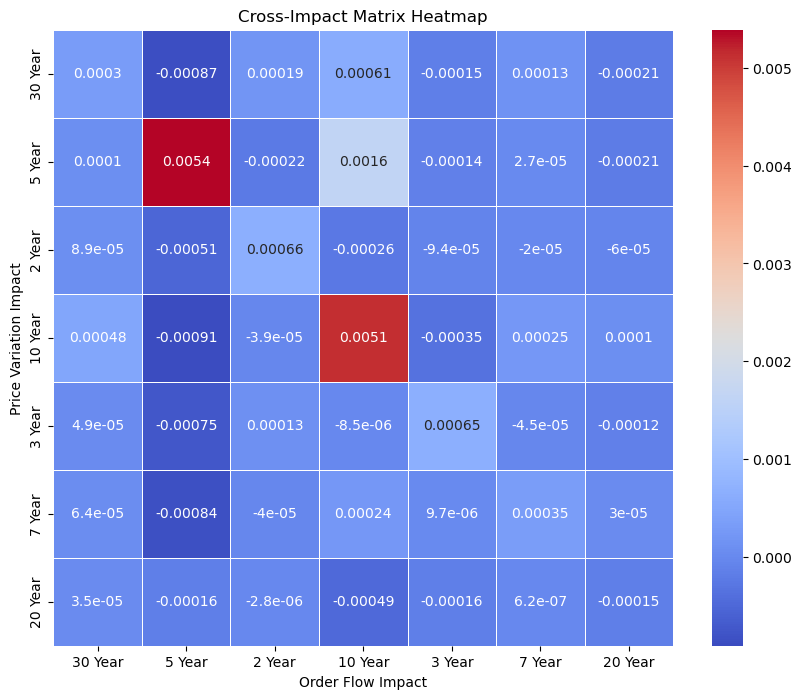

In [44]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

# Drop rows with missing values in either DataFrame to ensure consistent lengths
common_index = order_flow_matrix.dropna().index.intersection(price_variation_matrix.dropna().index)

order_flow_matrix = order_flow_matrix.loc[common_index]
price_variation_matrix = price_variation_matrix.loc[common_index]

# Step 5: Check if the price variation matrix still has zeroes
if price_variation_matrix.eq(0).all().all():
    print("Warning: All price variations are zero. Please check data sources or binning approach.")
else:
    print("Price variation matrix seems reasonable.")

# Step 6: Calculate Volatility of Order Flow and Price Variation
order_flow_volatility = order_flow_matrix.std()
price_volatility = price_variation_matrix.std()

# Step 7: Multivariate Linear Regression to Calculate Cross-Impact Matrix
n_assets = len(maturity_symbols)
cross_impact_matrix = np.zeros((n_assets, n_assets))

# Loop through each asset as the dependent variable
for i in range(n_assets):
    # Set the dependent variable (price variation for asset `i`)
    y = price_variation_matrix.iloc[:, i].values

    # Set the independent variables (order flows for all assets)
    X = order_flow_matrix.values

    # Check for length consistency before regression
    if X.shape[0] != len(y):
        print(f"Skipping asset {i} due to inconsistent sample sizes.")
        continue

    # Fit the linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Store the coefficients in the cross-impact matrix
    cross_impact_matrix[i, :] = model.coef_ * 10000

# Convert cross-impact matrix to DataFrame for better visualization
cross_impact_matrix_df = pd.DataFrame(cross_impact_matrix, index=maturity_symbols, columns=maturity_symbols)

# Step 8: Plot the Cross-Impact Matrix as a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cross_impact_matrix_df, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Cross-Impact Matrix Heatmap")
plt.xlabel("Order Flow Impact")
plt.ylabel("Price Variation Impact")
plt.show()

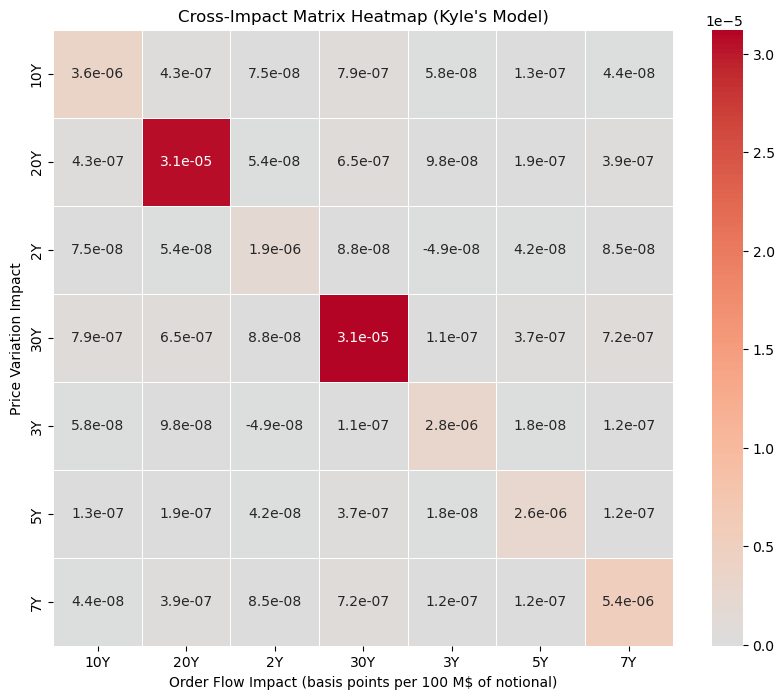

In [45]:
import numpy as np
import pandas as pd
from scipy.linalg import sqrtm, inv
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Calculate Covariance Matrices
# Covariance matrix of price variations (Σ)
price_variation_matrix = price_variation_matrix.dropna()  # Drop NaNs
Σ = price_variation_matrix.cov()

# Covariance matrix of order flows (Ω)
order_flow_matrix = order_flow_matrix.dropna()  # Drop NaNs
Ω = order_flow_matrix.cov()

# Ensure matrices have consistent dimensions
common_index = Σ.index.intersection(Ω.index)
Σ = Σ.loc[common_index, common_index]
Ω = Ω.loc[common_index, common_index]

# Step 2: Calculate the Inverse Square Root of Ω
Ω_inv_sqrt = inv(sqrtm(Ω))

# Step 3: Calculate the Kyle Cross-Impact Matrix (Λ)
#Λ_Kyle = Y * (Ω^-1/2)^T * sqrt((Ω^1/2)^T * Σ * Ω^1/2) * Ω^-1/2

# Calculate (Ω^1/2)
Ω_sqrt = sqrtm(Ω)

# Calculate the intermediate product: (Ω^1/2)^T * Σ * Ω^1/2
intermediate_product = Ω_sqrt.T @ Σ @ Ω_sqrt

# Calculate the square root of the intermediate product
sqrt_intermediate_product = sqrtm(intermediate_product)

# Finally, compute the Kyle Cross-Impact Matrix (Λ)
Λ_Kyle = Ω_inv_sqrt.T @ sqrt_intermediate_product @ Ω_inv_sqrt

# Step to Convert Complex to Real Values
# Explicitly take only the real part of Λ_Kyle to avoid issues during plotting
Λ_Kyle_real = np.real(Λ_Kyle)

# Convert Λ_Kyle to DataFrame for better visualization
cross_impact_matrix_df = pd.DataFrame(Λ_Kyle_real, index=common_index, columns=common_index)

# Step 4: Plot the Cross-Impact Matrix as a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cross_impact_matrix_df, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Cross-Impact Matrix Heatmap (Kyle's Model)")
plt.xlabel("Order Flow Impact (basis points per 100 M$ of notional)")
plt.ylabel("Price Variation Impact")
plt.show()

In [46]:
order_flow_matrix

,10Y,20Y,2Y,30Y,3Y,5Y,7Y
time,,,,,,,
2024-07-31 23:59:50,569.0,39.0,-2102.0,58.0,77.0,691.0,230.0
2024-08-01 09:30:00,9735.0,-4881.0,-14128.0,-1295.0,-5630.0,10389.0,-6158.0
2024-08-01 09:30:10,10074.0,-2434.0,-23570.0,-11.0,-5440.0,4982.0,2204.0
2024-08-01 09:30:20,1077.0,-1533.0,-6077.0,-155.0,3114.0,5086.0,-1252.0
2024-08-01 09:30:30,869.0,-964.0,-4194.0,-87.0,-1503.0,2118.0,-907.0
...,...,...,...,...,...,...,...
2024-10-31 15:59:00,-17866.0,-6744.0,-28058.0,3936.0,187.0,-14047.0,5765.0
2024-10-31 15:59:10,-21872.0,-9275.0,-11872.0,-1113.0,-8878.0,63861.0,-13404.0
2024-10-31 15:59:20,-7110.0,-5850.0,21469.0,1506.0,-20160.0,6381.0,-6761.0


Selected Pairs and Cross-Impact Coefficients:
   Asset1 Asset2  CrossImpact1_on_2  CrossImpact2_on_1
0     10Y    30Y       4.936772e-08       2.811638e-08
1      2Y     7Y      -5.947783e-09       6.534763e-08
2     10Y     2Y       1.847262e-08       2.785318e-08
3     30Y     5Y       2.356926e-08       4.885377e-07
4     30Y     7Y       1.889091e-08       4.897137e-07
5      2Y     5Y      -2.827618e-09       6.540386e-08
6     10Y     5Y       1.226336e-08       2.759141e-08
7     20Y     2Y      -2.208410e-08       5.524320e-07
8      2Y    30Y      -3.651468e-08       6.551748e-08
9      3Y     7Y      -1.311736e-08       6.616747e-08
10    10Y    20Y      -8.052992e-08       2.855485e-08
11    20Y     5Y       1.515590e-09       5.483260e-07
12    10Y     3Y      -1.187687e-08       2.836649e-08
13     5Y     7Y       3.040419e-09       3.414413e-08
14    30Y     3Y      -3.221002e-08       4.983317e-07
15    20Y     3Y      -1.554674e-08       5.518073e-07
16    20Y     7Y   

/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_1938/1185696603.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  selected_pairs = correlation_pairs.groupby('Bucket').apply(lambda x: x.sample(1)).reset_index(drop=True)
/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_1938/1185696603.py:51: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_data = pd.DataFrame(index=order_flow_matrix.columns, columns=order_flow_matrix.columns).fillna(0)
/var/folders/5w/5g

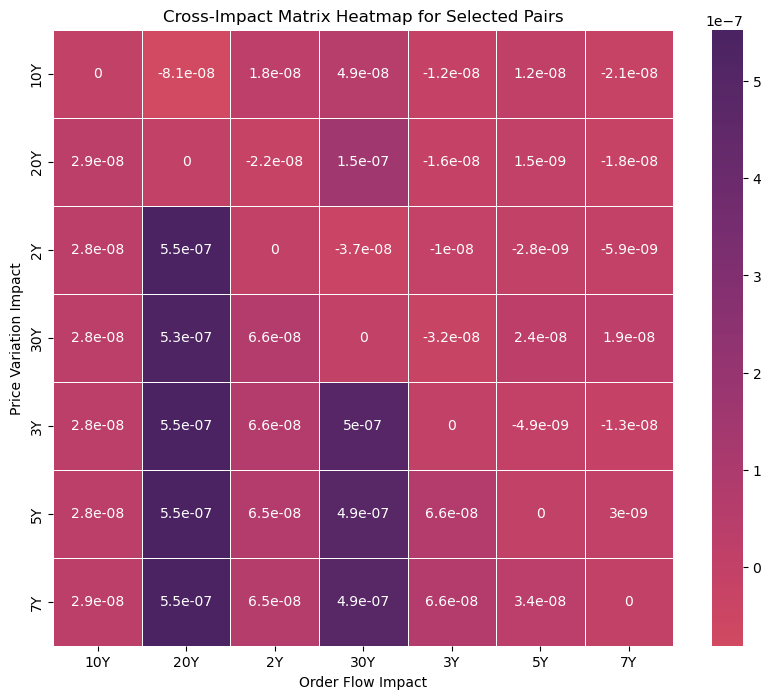

In [47]:
# Step 1: Calculate Correlation Matrix for Order Flow
correlation_matrix = order_flow_matrix.corr()

# Step 2: Extract Unique Pairs with Correlations
correlation_pairs = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
correlation_pairs = correlation_pairs.stack().reset_index()
correlation_pairs.columns = ['Asset1', 'Asset2', 'Correlation']

# Step 3: Create Equal-Sized Buckets for Correlations
num_buckets = 50
correlation_pairs['Bucket'] = pd.qcut(correlation_pairs['Correlation'], num_buckets, labels=False)

# Step 4: Select Random Pair from Each Bucket
selected_pairs = correlation_pairs.groupby('Bucket').apply(lambda x: x.sample(1)).reset_index(drop=True)

# Step 5: Perform Cross-Impact Analysis for Selected Pairs
selected_cross_impact = []

for _, row in selected_pairs.iterrows():
    asset1, asset2 = row['Asset1'], row['Asset2']

    # Prepare data for regression
    y = price_variation_matrix[asset1].values
    X = order_flow_matrix[[asset1, asset2]].values

    # Ensure dimensions match
    if len(y) != X.shape[0]:
        print(f"Skipping pair ({asset1}, {asset2}) due to size mismatch.")
        continue

    # Fit the Linear Regression Model
    model = LinearRegression()
    model.fit(X, y)

    # Save the results
    selected_cross_impact.append({
        'Asset1': asset1,
        'Asset2': asset2,
        'CrossImpact1_on_2': model.coef_[1],
        'CrossImpact2_on_1': model.coef_[0]
    })

# Convert to DataFrame for further analysis
selected_cross_impact_df = pd.DataFrame(selected_cross_impact)

# Step 6: Visualize Results
print("Selected Pairs and Cross-Impact Coefficients:")
print(selected_cross_impact_df)

# Optional: Heatmap of Cross-Impact for Selected Pairs
heatmap_data = pd.DataFrame(index=order_flow_matrix.columns, columns=order_flow_matrix.columns).fillna(0)

for _, row in selected_cross_impact_df.iterrows():
    asset1, asset2 = row['Asset1'], row['Asset2']
    heatmap_data.loc[asset1, asset2] = row['CrossImpact1_on_2']
    heatmap_data.loc[asset2, asset1] = row['CrossImpact2_on_1']

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    cmap="flare",     # Red-Blue color scheme (reversed to go from blue to red)
    center=0,          # Center the color scale at 0 for a balanced visualization
    linewidths=0.5,
    annot=True,)  # Enable annotations
plt.title("Cross-Impact Matrix Heatmap for Selected Pairs")
plt.xlabel("Order Flow Impact")
plt.ylabel("Price Variation Impact")
plt.show()


In [48]:
0

0

/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_1938/932182018.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  selected_pairs = correlation_pairs.groupby('Bucket').apply(lambda x: x.sample(1)).reset_index(drop=True)
/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_1938/932182018.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r2_heatmap = pd.DataFrame(index=order_flow_matrix.columns, columns=order_flow_matrix.columns).fillna(0)
/var/folders/5w/5gvvhg

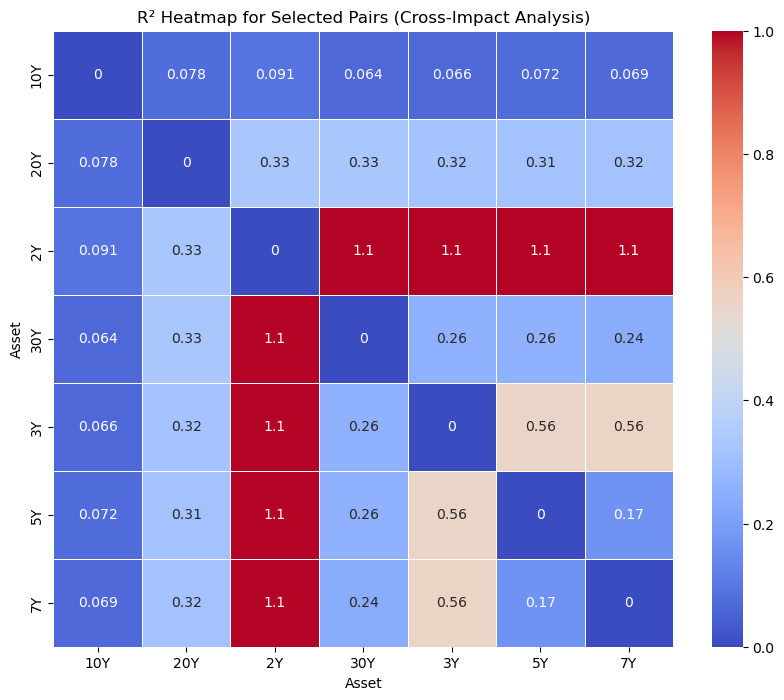

In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 1: Calculate Correlation Matrix for Order Flow
correlation_matrix = order_flow_matrix.corr()

# Step 2: Extract Unique Pairs with Correlations
correlation_pairs = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
correlation_pairs = correlation_pairs.stack().reset_index()
correlation_pairs.columns = ['Asset1', 'Asset2', 'Correlation']

# Step 3: Create Equal-Sized Buckets for Correlations
num_buckets = 50
correlation_pairs['Bucket'] = pd.qcut(correlation_pairs['Correlation'], num_buckets, labels=False)

# Step 4: Select Random Pair from Each Bucket
selected_pairs = correlation_pairs.groupby('Bucket').apply(lambda x: x.sample(1)).reset_index(drop=True)

# Step 5: Perform Cross-Impact Analysis for Selected Pairs and Compute R²
r2_values = []

# Create an empty matrix for R²
r2_heatmap = pd.DataFrame(index=order_flow_matrix.columns, columns=order_flow_matrix.columns).fillna(0)

for _, row in selected_pairs.iterrows():
    asset1, asset2 = row['Asset1'], row['Asset2']

    # Prepare data for regression
    y = price_variation_matrix[asset1].values
    X = order_flow_matrix[[asset1, asset2]].values

    # Ensure dimensions match
    if len(y) != X.shape[0]:
        print(f"Skipping pair ({asset1}, {asset2}) due to size mismatch.")
        continue

    # Fit the Linear Regression Model
    model = LinearRegression()
    model.fit(X, y)

    # Predicted price variations
    predicted_price_variations = model.predict(X)

    # Compute R² using the sklearn's r2_score function
    r2 = r2_score(y, predicted_price_variations)

    # Save the R² value for the pair
    r2_values.append({
        'Asset1': asset1,
        'Asset2': asset2,
        'R2': r2
    })

    # Fill the R² values into the heatmap (symmetric)
    r2_heatmap.loc[asset1, asset2] = r2*1000
    r2_heatmap.loc[asset2, asset1] = r2*1000

# Step 6: Visualize the R² Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(r2_heatmap, cmap="coolwarm", linewidths=0.5, annot=True, vmin=0, vmax=1)  # Annotations and color scaling
plt.title("R² Heatmap for Selected Pairs (Cross-Impact Analysis)")
plt.xlabel("Asset")
plt.ylabel("Asset")
plt.show()


In [50]:
r2_values

[{'Asset1': '10Y', 'Asset2': '30Y', 'R2': 6.377784040301204e-05},
 {'Asset1': '2Y', 'Asset2': '7Y', 'R2': 0.001135139181156819},
 {'Asset1': '10Y', 'Asset2': '2Y', 'R2': 9.129082543812839e-05},
 {'Asset1': '30Y', 'Asset2': '5Y', 'R2': 0.00025731151902586014},
 {'Asset1': '30Y', 'Asset2': '7Y', 'R2': 0.00024011695576620085},
 {'Asset1': '2Y', 'Asset2': '5Y', 'R2': 0.0011345751465823284},
 {'Asset1': '10Y', 'Asset2': '5Y', 'R2': 7.16694447076005e-05},
 {'Asset1': '20Y', 'Asset2': '2Y', 'R2': 0.00032863637198521367},
 {'Asset1': '2Y', 'Asset2': '30Y', 'R2': 0.0011410246907958},
 {'Asset1': '3Y', 'Asset2': '7Y', 'R2': 0.0005624539840958231},
 {'Asset1': '10Y', 'Asset2': '20Y', 'R2': 7.785980156826966e-05},
 {'Asset1': '20Y', 'Asset2': '5Y', 'R2': 0.00031256422966874364},
 {'Asset1': '10Y', 'Asset2': '3Y', 'R2': 6.601081506418804e-05},
 {'Asset1': '5Y', 'Asset2': '7Y', 'R2': 0.000166082234570486},
 {'Asset1': '30Y', 'Asset2': '3Y', 'R2': 0.0002606347936460196},
 {'Asset1': '20Y', 'Asset2': 

/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_1938/1654039564.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r2_heatmap = pd.DataFrame(index=sorted_assets, columns=sorted_assets).fillna(0)  # Initialize with zeros
/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_1938/1654039564.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.26059588777882503' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  r2_heatmap.loc[target_asset, sorted_assets[j - 1]] = r2 * 10000  # Scale for visualization
/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_1938/1654039564.py:52: FutureWarning: Setting an item of incompatible dtype 

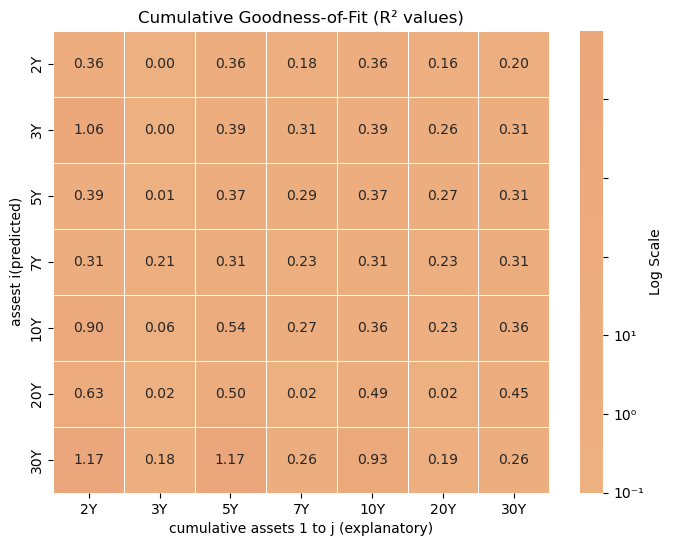

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from matplotlib.colors import LogNorm

# Step 1: Calculate Correlation Matrix for Order Flow
correlation_matrix = order_flow_matrix.corr()

# Step 2: Sort Assets by Correlation Magnitude
# Calculate the average correlation for each asset and sort by this value
avg_correlation = correlation_matrix.abs().mean().sort_values(ascending=False)
sorted_assets = avg_correlation.index.tolist()

# Step 3: Perform Cumulative Cross-Impact Analysis
r2_heatmap = pd.DataFrame(index=sorted_assets, columns=sorted_assets).fillna(0)  # Initialize with zeros

for i, target_asset in enumerate(sorted_assets):
    r2_cumulative = []

    for j in range(1, len(sorted_assets) + 1):
        # Select the first j explanatory assets cumulatively
        explanatory_assets = sorted_assets[:j]

        # Ensure the target asset is not used as an explanatory variable
        if target_asset in explanatory_assets:
            explanatory_assets.remove(target_asset)

        # Prepare data for regression
        y = price_variation_matrix[target_asset].dropna().values
        X = order_flow_matrix[explanatory_assets].iloc[:len(y)].values  # Ensure dimensions match

        # Check if there's enough data to fit the model
        if X.shape[0] == 0 or X.shape[1] == 0:
            r2_cumulative.append(np.nan)  # Append NaN if not enough data
            continue

        # Fit the Linear Regression Model
        model = LinearRegression()
        model.fit(X, y)

        # Predicted price variations
        predicted_price_variations = model.predict(X)

        # Compute R² using the sklearn's r2_score function
        r2 = r2_score(y, predicted_price_variations)
        r2_cumulative.append(r2)

        # Store the cumulative R² value in the heatmap
        r2_heatmap.loc[target_asset, sorted_assets[j - 1]] = r2 * 10000  # Scale for visualization

# Step 4: Reorder Matrix Based on a Specific Order
order = ['2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
valid_order = [label for label in order if label in r2_heatmap.index]

# Reindex the DataFrame to match the specified order
r2_heatmap = r2_heatmap.reindex(index=valid_order, columns=valid_order)

# Fill missing values (NaN) with 0 or another placeholder (e.g., np.nan for a more neutral approach)
r2_heatmap = r2_heatmap.fillna(0)

# Plot the heatmap with linear scale values but log scale color bar
plt.figure(figsize=(8, 6))
ax = sns.heatmap(r2_heatmap,
                 annot=True,
                 fmt=".2f",
                 cmap='flare',
                 center=15,
                 linewidths=0.5)

# Customize the colorbar to be logarithmic
cbar = ax.collections[0].colorbar
cbar.set_ticklabels(['10⁻¹', '10⁰', '10¹'])
cbar.set_label('Log Scale')

# Customize labels and title
plt.title("Cumulative Goodness-of-Fit (R² values)")
plt.xlabel("cumulative assets 1 to j (explanatory)")
plt.ylabel("assest i(predicted)")

# Show the plot
plt.show()
r2_heatmap.to_csv('cumulative_r2.csv',index = False)

/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_1938/4221190455.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  selected_pairs = correlation_pairs.groupby('Bucket').apply(lambda x: x.sample(n=min(len(x), 30))).reset_index(drop=True)
/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_1938/4221190455.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  selected_pairs = correlation_pairs.groupby('Bucket').apply(lambda x: x.sample(n=min(len(x), 30))).reset_index(drop=True)
/var/folders/5w

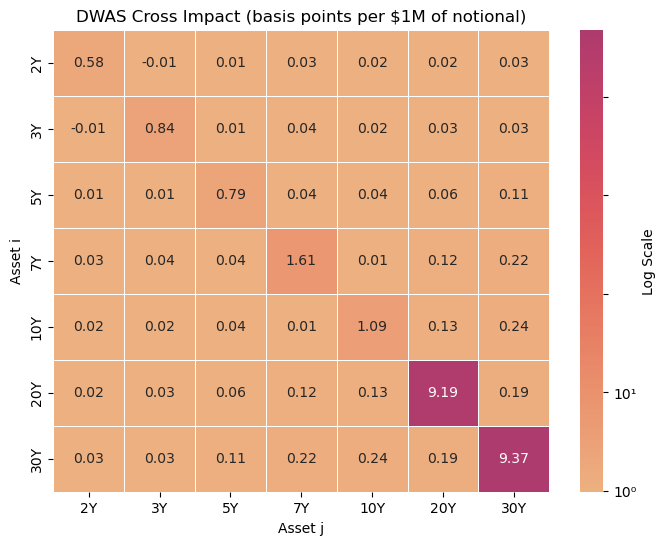

In [68]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import sqrtm
from numpy.linalg import inv

# Step 1: Calculate Covariance Matrices
price_variation_matrix = price_variation_matrix.dropna()  # Drop NaNs
Σ = price_variation_matrix.cov()

order_flow_matrix = order_flow_matrix.dropna()  # Drop NaNs
Ω = order_flow_matrix.cov()

# Ensure matrices have consistent dimensions
common_index = Σ.index.intersection(Ω.index)
Σ = Σ.loc[common_index, common_index]
Ω = Ω.loc[common_index, common_index]

# Step 2: Pair Selection Based on Correlation Buckets
correlation_matrix = price_variation_matrix.corr()

# Flatten correlation matrix to get pairs
correlation_pairs = correlation_matrix.unstack().reset_index()
correlation_pairs.columns = ['Asset 1', 'Asset 2', 'Correlation']

# Remove self-pairs and duplicates
correlation_pairs = correlation_pairs[correlation_pairs['Asset 1'] != correlation_pairs['Asset 2']]
correlation_pairs = correlation_pairs.drop_duplicates(subset=['Correlation'])

# Define correlation buckets (e.g., 50 buckets)
n_buckets = 50
correlation_pairs['Bucket'] = pd.qcut(correlation_pairs['Correlation'], q=n_buckets, duplicates='drop')

# Select a fixed number of pairs from each bucket (e.g., 30 pairs per bucket)
selected_pairs = correlation_pairs.groupby('Bucket').apply(lambda x: x.sample(n=min(len(x), 30))).reset_index(drop=True)

# Filter covariance matrices for selected pairs
selected_assets = pd.unique(selected_pairs[['Asset 1', 'Asset 2']].values.ravel())
Σ = Σ.loc[selected_assets, selected_assets]
Ω = Ω.loc[selected_assets, selected_assets]

# Step 3: Kyle Cross-Impact Matrix Calculation
Ω_inv_sqrt = inv(sqrtm(Ω))
Ω_sqrt = sqrtm(Ω)

# Intermediate product: (Ω^1/2)^T * Σ * Ω^1/2
intermediate_product = Ω_sqrt.T @ Σ @ Ω_sqrt
sqrt_intermediate_product = sqrtm(intermediate_product)

# Calculate the Kyle Cross-Impact Matrix (Λ)
Λ_Kyle = Ω_inv_sqrt.T @ sqrt_intermediate_product @ Ω_inv_sqrt
Λ_Kyle_real = np.real(Λ_Kyle) * 300000  # Take the real part to avoid complex values

cross_impact_matrix_df = pd.DataFrame(Λ_Kyle_real, index=selected_assets, columns=selected_assets)

# Step 4: Reorder Matrix Based on a Specific Order
order = ['2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
valid_order = [label for label in order if label in cross_impact_matrix_df.index]

# Reindex the DataFrame to match the specified order
cross_impact_matrix_df = cross_impact_matrix_df.reindex(index=valid_order, columns=valid_order)

# Step 5: Plot the Heatmap with Log-Normal Scale for Color Bar
plt.figure(figsize=(8, 6))

# Plot heatmap
ax = sns.heatmap(cross_impact_matrix_df,
                 annot=True,
                 fmt=".2f",
                 cmap="flare",
                 center=8,
                 linewidths=0.5)

# Customize the colorbar to be logarithmic
cbar = ax.collections[0].colorbar
cbar.set_ticklabels(['10⁻¹', '10⁰', '10¹'])
cbar.set_label('Log Scale')
# Customize labels and title
plt.title("DWAS Cross Impact (basis points per $1M of notional)")
plt.xlabel("Asset j")
plt.ylabel("Asset i")

plt.show()

cross_impact_matrix_df.to_csv('cross_impact_matrix.csv',index = False)

In [53]:
cross_impact_matrix_df

,2Y,3Y,5Y,7Y,10Y,20Y,30Y
2Y,0.582040,-0.014751,0.012508,0.025504,0.022384,0.016101,0.026365
3Y,-0.014751,0.839040,0.005431,0.035164,0.017483,0.029497,0.032172
5Y,0.012508,0.005431,0.792593,0.035048,0.039816,0.056876,0.111716
7Y,0.025504,0.035164,0.035048,1.610381,0.013187,0.117788,0.216082
10Y,0.022384,0.017483,0.039816,0.013187,1.094420,0.129040,0.236723
20Y,0.016101,0.029497,0.056876,0.117788,0.129040,9.187486,0.194266
30Y,0.026365,0.032172,0.111716,0.216082,0.236723,0.194266,9.365936


In [54]:
import numpy as np
import pandas as pd
from scipy.linalg import sqrtm, inv
from sklearn.metrics import r2_score
# Split point
split_point = int(len(price_variation_matrix) * (2.5/ 3))

# In-sample
price_variation_in_sample = price_variation_matrix.iloc[:split_point]
order_flow_in_sample = order_flow_matrix.iloc[:split_point]

# Out-of-sample data
price_variation_out_sample = price_variation_matrix.iloc[split_point:]
order_flow_out_sample = order_flow_matrix.iloc[split_point:]

# Covariance matrices for in-sample data
Σ_in_sample = price_variation_in_sample.cov()
Ω_in_sample = order_flow_in_sample.cov()

# Ensure the matrices have the same index
common_index = Σ_in_sample.index.intersection(Ω_in_sample.index)
Σ_in_sample = Σ_in_sample.loc[common_index, common_index]
Ω_in_sample = Ω_in_sample.loc[common_index, common_index]

# Kyle Model computation
Ω_inv_sqrt = inv(sqrtm(Ω_in_sample))  # Inverse square root of Ω
Ω_sqrt = sqrtm(Ω_in_sample)           # Square root of Ω

intermediate_product = Ω_sqrt.T @ Σ_in_sample @ Ω_sqrt
sqrt_intermediate_product = sqrtm(intermediate_product)

Λ_Kyle = Ω_inv_sqrt.T @ sqrt_intermediate_product @ Ω_inv_sqrt

# Predicted price variations = Λ_Kyle * Order Flow
predicted_price_variations = order_flow_out_sample.values @ Λ_Kyle
actual_price_variations = price_variation_out_sample.values

# Generalized R² function
def generalized_r2(realized, predicted, M):
    """
    Compute the M-weighted generalized R² score.

    Parameters:
    - realized: np.array of shape (N, n), realized price changes.
    - predicted: np.array of shape (N, n), predicted price changes.
    - M: np.array of shape (n, n), symmetric, positive definite weight matrix.

    Returns:
    - R²(M) score: float
    """
    residuals = realized - predicted

    # Numerator: sum of M-weighted squared residuals
    numerator = sum(residual.T @ M @ residual for residual in residuals)

    # Denominator: sum of M-weighted squared realized price changes
    denominator = sum(real.T @ M @ real for real in realized)

    # Generalized R² score
    r2_m = 1 - (numerator / denominator)

    return r2_m

# Choose M (e.g., identity matrix or inverse covariance matrix)
M = inv(Σ_in_sample)

# Compute the generalized R² score
r2_m_score = generalized_r2(actual_price_variations,predicted_price_variations, M)

print(f"Generalized R²(M) Score: {r2_m_score}")

predicted_price_variations

Generalized R²(M) Score: -0.6808382674816817


array([[-0.00233216,  0.00782332,  0.00198259, ..., -0.00193083,
        -0.00474339, -0.00117315],
       [-0.02357357,  0.05226715,  0.00696533, ..., -0.00520241,
        -0.01735671,  0.01472531],
       [-0.015247  ,  0.06115722,  0.02118469, ..., -0.00307008,
         0.02984343,  0.00917001],
       ...,
       [-0.0280225 , -0.18711254,  0.03613427, ..., -0.05688335,
         0.01386196, -0.03492034],
       [-0.13250475, -0.33832174,  0.06342772, ...,  0.04001131,
         0.07585597, -0.06367458],
       [-0.07110644, -0.30689472,  0.02528919, ..., -0.14248356,
        -0.02742611, -0.21085992]])

In [55]:
split_point = int(len(price_variation_matrix) * (1.5 / 3))

# In-sample data
price_variation_in_sample = price_variation_matrix.iloc[:split_point]
order_flow_in_sample = order_flow_matrix.iloc[:split_point]

# Out-of-sample data
price_variation_out_sample = price_variation_matrix.iloc[split_point:]
order_flow_out_sample = order_flow_matrix.iloc[split_point:]

# Compute daily price variations (∆p)
price_variation_daily = price_variation_in_sample.diff().dropna()
# Compute daily signed order flows (q)
order_flow_daily = order_flow_in_sample.diff().dropna()

# Volatility estimators (standard deviation) for price increments and signed order flows
σ_tk = price_variation_daily.std(axis=0)  # σ_tk for price increments
ω_tk = order_flow_daily.std(axis=0)  # ω_tk for signed order flows

ρ_Δp = np.diag(1 / σ_tk.values) @ price_variation_in_sample.corr() @ np.diag(1 / σ_tk.values)
ρ_q = np.diag(1 / ω_tk.values) @ order_flow_in_sample.corr() @ np.diag(1 / ω_tk.values)
ρ_Δp_q = np.diag(1 / σ_tk.values) @ price_variation_in_sample.corrwith(order_flow_in_sample).values @ np.diag(1 / ω_tk.values)

ρ_Δp_long = ρ_Δp.mean()
ρ_q_long = ρ_q.mean()
ρ_Δp_q_long = ρ_Δp_q.mean()

# Compute the covariance and response matrices for each day tk
Σ_tk = np.diag(σ_tk.values) @ ρ_Δp @ np.diag(σ_tk.values)
Ω_tk = np.diag(ω_tk.values) @ ρ_q @ np.diag(ω_tk.values)
R_tk = np.diag(σ_tk.values) @ ρ_Δp_q @ np.diag(ω_tk.values)

# Kyle Model computation
Ω_inv_sqrt = inv(sqrtm(Ω_tk))  # Inverse square root of Ω
Ω_sqrt = sqrtm(Ω_tk)           # Square root of Ω
intermediate_product = Ω_sqrt.T @ Σ_tk @ Ω_sqrt
sqrt_intermediate_product = sqrtm(intermediate_product)
Λ_Kyle = Ω_inv_sqrt.T @ sqrt_intermediate_product @ Ω_inv_sqrt

# Predicted price variations = Λ_Kyle * Order Flow
predicted_price_variations = order_flow_out_sample.values @ Λ_Kyle
actual_price_variations = price_variation_out_sample.values


In [56]:
import numpy as np
import pandas as pd

# Set the number of trading days (252)
num_trading_days = 252

# Compute daily volatilities for price increments and signed order flows
price_variation_daily = price_variation_in_sample.diff().dropna()
order_flow_daily = order_flow_in_sample.diff().dropna()

# Calculate 252-day rolling volatility for price increments (σ_tk) and signed order flows (ω_tk)
σ_252 = price_variation_daily.rolling(window=num_trading_days).std().iloc[-1]  # Volatility for price increments using 252 days
ω_252 = order_flow_daily.rolling(window=num_trading_days).std().iloc[-1]  # Volatility for signed order flows using 252 days

# Compute correlation matrices for price variations and order flows
rho_delta_p = np.diag(1 / σ_252.values) @ price_variation_in_sample.corr() @ np.diag(1 / σ_252.values)
rho_q = np.diag(1 / ω_252.values) @ order_flow_in_sample.corr() @ np.diag(1 / ω_252.values)

# Compute the cross-correlation matrix between price variations and order flows (ρ_Δp,q)
# Here we use correlation of price variation and order flow for cross-correlation calculation
rho_delta_p_q = np.diag(1 / σ_252.values) @ price_variation_in_sample.corrwith(order_flow_in_sample).values @ np.diag(1 / ω_252.values)

# Now, Sigma_t, Omega_t, and R_t are computed as follows:
sigma_diag = np.diag(σ_252)  # Diagonal matrix for normalized price volatility
omega_diag = np.diag(ω_252)  # Diagonal matrix for normalized order flow volatility

Sigma_t = sigma_diag @ rho_delta_p @ sigma_diag
Omega_t = omega_diag @ rho_q @ omega_diag
R_t = sigma_diag @ rho_delta_p_q @ omega_diag

# Compute Omega_t inverse square root and Sigma_t square root for cross-impact matrix
Omega_t_inv_sqrt = np.linalg.inv(np.sqrt(Omega_t))  # Inverse square root of Ω
Sigma_t_sqrt = np.sqrt(Sigma_t)  # Square root of Σ

# Compute the cross-impact matrix Lambda_t
Lambda_t = Omega_t_inv_sqrt.T @ Sigma_t_sqrt @ Omega_t_inv_sqrt

# Example: Order flow imbalance at time t (qt)
q_t = order_flow_in_sample.iloc[0].values  # First row as an example

# Ensure q_t is a column vector (for matrix multiplication)
q_t = q_t.reshape(-1, 1)

# Predict price change Δp_t
predicted_price_change = Lambda_t @ q_t  # Cross-impact matrix multiplied by order flow imbalance
Omega_t

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)


,0,1,2,3,4,5,6
0,1.000000,0.044124,0.018380,-0.023321,0.043575,0.007841,0.056329
1,0.044124,1.000000,0.003356,0.075859,0.052854,0.042042,0.051252
2,0.018380,0.003356,1.000000,0.030297,0.107562,0.013354,-0.007585
3,-0.023321,0.075859,0.030297,1.000000,0.053607,0.003057,0.029587
4,0.043575,0.052854,0.107562,0.053607,1.000000,0.038926,0.060056
5,0.007841,0.042042,0.013354,0.003057,0.038926,1.000000,0.047632
6,0.056329,0.051252,-0.007585,0.029587,0.060056,0.047632,1.000000


In [57]:
market_data

{'2Y':                                           time_bin  cumulative_size  \
 0       (2024-07-31 23:59:50, 2024-08-01 00:00:00]             3742   
 1       (2024-08-01 09:30:00, 2024-08-01 09:30:10]            79336   
 2       (2024-08-01 09:30:10, 2024-08-01 09:30:20]            80370   
 3       (2024-08-01 09:30:20, 2024-08-01 09:30:30]            39697   
 4       (2024-08-01 09:30:30, 2024-08-01 09:30:40]            20526   
 ...                                            ...              ...   
 215367  (2024-10-31 15:59:10, 2024-10-31 15:59:20]           380428   
 215368  (2024-10-31 15:59:20, 2024-10-31 15:59:30]           335117   
 215369  (2024-10-31 15:59:30, 2024-10-31 15:59:40]           329124   
 215370  (2024-10-31 15:59:40, 2024-10-31 15:59:50]           506492   
 215371  (2024-10-31 15:59:50, 2024-10-31 16:00:00]           575829   
 
              price  signed_size                time        date  \
 0       100.181641        -2102 2024-07-31 23:59:50  2024-0

In [58]:
import numpy as np
import pandas as pd
from scipy.linalg import sqrtm, inv

def calculate_cross_impact_metrics(market_data, num_bins=10):
    # Calculate binned metrics (price variation, order flow, volatilities)
    combined_data = calculate_metrics_with_bin(market_data, num_bins)
    binned_metrics = pd.concat([
        metrics[symbol][['price_variation', 'order_flow', 'order_flow_volatility']].dropna()
        for symbol in metrics.keys()
    ], axis=0).reset_index(drop=True)

    # Compute daily volatilities for price and order flow
    σ_tk = binned_metrics['price_variation'].values
    ω_tk = binned_metrics['order_flow_volatility'].values

    # Compute correlation matrices
    ρ_Δp = np.diag(1 / σ_tk) @ market_data['price_variation'].corr() @ np.diag(1 / σ_tk)
    ρ_q = np.diag(1 / ω_tk) @ market_data['order_flow'].corr() @ np.diag(1 / ω_tk)
    ρ_Δp_q = np.diag(1 / σ_tk) @ market_data['price_variation'].corrwith(market_data['order_flow']).values @ np.diag(1 / ω_tk)

    # Construct covariance matrices Σ_t, Ω_t, and R_t
    Σ_t = np.diag(σ_tk) @ ρ_Δp @ np.diag(σ_tk)
    Ω_t = np.diag(ω_tk) @ ρ_q @ np.diag(ω_tk)
    R_t = np.diag(σ_tk) @ ρ_Δp_q @ np.diag(ω_tk)

    # Compute cross-impact matrix Λ_t
    Ω_t_inv_sqrt = inv(sqrtm(Ω_t))  # Inverse square root of Ω
    Σ_t_sqrt = sqrtm(Σ_t)  # Square root of Σ

    Λ_t = Ω_t_inv_sqrt.T @ Σ_t_sqrt @ Ω_t_inv_sqrt

    return Λ_t, binned_metrics

# Calculate the cross-impact matrix Λ_t and the binned metrics
Λ_t, binned_metrics = calculate_cross_impact_metrics(market_data, 10)

# Example: Use the cross-impact matrix to predict price change based on order flow
order_flow_at_t = market_data['order_flow'].iloc[0].values  # Adjust based on your time window
predicted_price_change = Λ_t @ order_flow_at_t

# Output the predicted price change
print(predicted_price_change)


/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_1938/818878723.py:18: RuntimeWarning: divide by zero encountered in divide
  ρ_Δp = np.diag(1 / σ_tk) @ market_data['price_variation'].corr() @ np.diag(1 / σ_tk)


KeyError: 'price_variation'

In [ ]:
M = inv(Σ_tk)

# Generalized R²(M) calculation
def generalized_r2(realized, predicted, M):
    """
    Compute the M-weighted generalized R² score.
    Parameters:
    - realized: np.array of shape (N, n), realized price changes.
    - predicted: np.array of shape (N, n), predicted price changes.
    - M: np.array of shape (n, n), symmetric, positive definite weight matrix.
    Returns:
    - R²(M) score: float
    """
    residuals = realized - predicted

    # Numerator: sum of M-weighted squared residuals
    numerator = np.sum([np.dot(residual.T, M).dot(residual) for residual in residuals])

    # Denominator: sum of M-weighted squared realized price changes
    denominator = np.sum([np.dot(real.T, M).dot(real) for real in realized])

    # Generalized R² score
    r2_m = 1 - (numerator / denominator)

    return r2_m

# Compute the generalized R² score
r2_m_score = generalized_r2(actual_price_variations, predicted_price_variations, M)

print(f"Generalized R²(M) Score: {r2_m_score}")

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Step 1: Calculate Covariance Matrices (as done previously)
price_variation_matrix = price_variation_matrix.dropna()  # Drop NaNs
Σ = price_variation_matrix.cov()

order_flow_matrix = order_flow_matrix.dropna()  # Drop NaNs
Ω = order_flow_matrix.cov()

# Ensure matrices have consistent dimensions
common_index = Σ.index.intersection(Ω.index)
Σ = Σ.loc[common_index, common_index]
Ω = Ω.loc[common_index, common_index]

# Step 2: Pair Selection Based on Correlation Buckets
correlation_matrix = price_variation_matrix.corr()

# Flatten correlation matrix to get pairs
correlation_pairs = correlation_matrix.unstack().reset_index()
correlation_pairs.columns = ['Asset 1', 'Asset 2', 'Correlation']

# Remove self-pairs and duplicates
correlation_pairs = correlation_pairs[correlation_pairs['Asset 1'] != correlation_pairs['Asset 2']]
correlation_pairs = correlation_pairs.drop_duplicates(subset=['Correlation'])

# Define correlation buckets (e.g., 50 buckets)
n_buckets = 50
correlation_pairs['Bucket'] = pd.qcut(correlation_pairs['Correlation'], q=n_buckets, duplicates='drop')

# Select a fixed number of pairs from each bucket (e.g., 20 pairs per bucket)
selected_pairs = correlation_pairs.groupby('Bucket').apply(lambda x: x.sample(n=min(len(x), 30))).reset_index(drop=True)

# Filter covariance matrices for selected pairs
selected_assets = pd.unique(selected_pairs[['Asset 1', 'Asset 2']].values.ravel())
Σ = Σ.loc[selected_assets, selected_assets]
Ω = Ω.loc[selected_assets, selected_assets]

# Step 3: Kyle Cross-Impact Matrix Calculation
Ω_inv_sqrt = inv(sqrtm(Ω))
Ω_sqrt = sqrtm(Ω)

# Intermediate product: (Ω^1/2)^T * Σ * Ω^1/2
intermediate_product = Ω_sqrt.T @ Σ @ Ω_sqrt
sqrt_intermediate_product = sqrtm(intermediate_product)

# Calculate the Kyle Cross-Impact Matrix (Λ)
Λ_Kyle = Ω_inv_sqrt.T @ sqrt_intermediate_product @ Ω_inv_sqrt
Λ_Kyle_real = np.real(Λ_Kyle)  # Take the real part to avoid complex values

# Step 4: Predicted Price Variations (using matrix multiplication)
# Prepare order flow data for all pairs
X = order_flow_matrix[selected_assets].values  # This is a matrix of size (N, M), where N is the number of samples and M is the number of assets

# Predicted price variations (for all assets) using matrix multiplication
predicted_price_variations = X @ Λ_Kyle_real  # This gives a matrix of size (N, M)

# Actual price variations (for all assets)
actual_price_variations = price_variation_matrix[selected_assets].values  # This gives a matrix of size (N, M)

# Step 5: Calculate R² for all pairs (R² is calculated as 1 - residual sum of squares / total sum of squares)
# Calculate residuals
residuals = actual_price_variations - predicted_price_variations

# Calculate the total sum of squares (denominator)
denominator = np.sum((actual_price_variations - np.mean(actual_price_variations, axis=0)) ** 2, axis=0)

# Calculate the residual sum of squares (numerator)
numerator = np.sum(residuals ** 2, axis=0)

# R² for each asset pair
r2_values = 1 - (numerator / denominator)


In [ ]:
r2_heatmap = pd.DataFrame(index=order_flow_matrix.columns, columns=order_flow_matrix.columns).fillna(0)

# Populate the heatmap using the `Out_of_Sample_R2` column
for _, row in selected_cross_impact_df.iterrows():
    asset1 = row['Asset1']
    asset2 = row['Asset2']

    # Ensure the R² value exists
    if 'Out_of_Sample_R2' in row:
        r2 = row['Out_of_Sample_R2']
    else:
        print(f"Skipping pair ({asset1}, {asset2}) due to missing R².")
        continue

    # Assign R² to the heatmap
    r2_heatmap.loc[asset1, asset2] = max(r2, 0)  # Ensure non-negative R²

# Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(r2_heatmap.astype(float), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("R² Heatmap for Selected Pairs")
plt.xlabel("Explanatory Asset (Asset 2)")
plt.ylabel("Predicted Asset (Asset 1)")
plt.show()



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 1: Calculate Covariance Matrices
price_variation_matrix = price_variation_matrix.dropna()  # Drop NaNs
Σ = price_variation_matrix.cov()

order_flow_matrix = order_flow_matrix.dropna()  # Drop NaNs
Ω = order_flow_matrix.cov()

# Ensure matrices have consistent dimensions
common_index = Σ.index.intersection(Ω.index)
Σ = Σ.loc[common_index, common_index]
Ω = Ω.loc[common_index, common_index]

# Step 2: Extract Unique Pairs and Remove Self-Pairs and Duplicates
correlation_matrix = price_variation_matrix.corr()

# Flatten correlation matrix to get pairs (excluding self-pairs and duplicates)
correlation_pairs = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
correlation_pairs = correlation_pairs.stack().reset_index()
correlation_pairs.columns = ['Asset1', 'Asset2', 'Correlation']

# Remove self-pairs (Asset cannot be compared with itself)
correlation_pairs = correlation_pairs[correlation_pairs['Asset1'] != correlation_pairs['Asset2']]

# Remove duplicate pairs (asset1 vs asset2 and asset2 vs asset1 should be considered the same)
correlation_pairs = correlation_pairs[correlation_pairs.apply(lambda x: (x['Asset1'], x['Asset2']) < (x['Asset2'], x['Asset1']), axis=1)]

# Step 3: Create Equal-Sized Buckets for Correlations
num_buckets = 50
correlation_pairs['Bucket'] = pd.qcut(correlation_pairs['Correlation'], num_buckets, labels=False, duplicates='drop')

# Step 4: Select Random Pair from Each Bucket
selected_pairs = correlation_pairs.groupby('Bucket').apply(lambda x: x.sample(1)).reset_index(drop=True)

# Step 5: Initialize the delta_r2_matrix to store the ΔR² values for each pair of assets
delta_r2_matrix = pd.DataFrame(index=price_variation_matrix.columns, columns=price_variation_matrix.columns).fillna(0)

# Step 6: Loop through selected pairs and compute ΔR² (out-of-sample accuracy)
for _, row in selected_pairs.iterrows():
    asset1, asset2 = row['Asset1'], row['Asset2']

    # Prepare data for regression (predicting asset1 using asset2's order flow)
    y1 = price_variation_matrix[asset1].values
    X1 = order_flow_matrix[[asset1, asset2]].values

    # Ensure the dimensions match for regression
    if len(y1) != X1.shape[0]:
        print(f"Skipping pair ({asset1}, {asset2}) due to size mismatch.")
        continue

    # Fit a linear regression model for asset1 (predicted) using asset2 (explanatory)
    model1 = LinearRegression()
    model1.fit(X1, y1)
    y_pred1 = model1.predict(X1)
    r2_1 = r2_score(y1, y_pred1)

    # Prepare data for regression (predicting asset2 using asset1's order flow)
    y2 = price_variation_matrix[asset2].values
    X2 = order_flow_matrix[[asset1, asset2]].values

    # Fit a linear regression model for asset2 (predicted) using asset1 (explanatory)
    model2 = LinearRegression()
    model2.fit(X2, y2)
    y_pred2 = model2.predict(X2)
    r2_2 = r2_score(y2, y_pred2)

    # Assign average of both directions' R² values to maintain symmetry
    delta_r2_matrix.loc[asset1, asset2] = r2_1
    delta_r2_matrix.loc[asset2, asset1] = r2_2

# Step 7: Visualize the ΔR² matrix with a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(delta_r2_matrix, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5, center=0)
plt.title("Out-of-Sample Added Accuracy (ΔR²) Matrix")
plt.xlabel("Asset j (explanatory)")
plt.ylabel("Asset i (predicted)")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 1: Calculate Covariance Matrices
price_variation_matrix = price_variation_matrix.dropna()  # Drop NaNs
Σ = price_variation_matrix.cov()

order_flow_matrix = order_flow_matrix.dropna()  # Drop NaNs
Ω = order_flow_matrix.cov()

# Ensure matrices have consistent dimensions
common_index = Σ.index.intersection(Ω.index)
Σ = Σ.loc[common_index, common_index]
Ω = Ω.loc[common_index, common_index]

# Step 2: Extract Unique Pairs and Remove Self-Pairs and Duplicates
correlation_matrix = price_variation_matrix.corr()

# Flatten correlation matrix to get pairs (excluding self-pairs and duplicates)
correlation_pairs = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
correlation_pairs = correlation_pairs.stack().reset_index()
correlation_pairs.columns = ['Asset1', 'Asset2', 'Correlation']

# Remove self-pairs (Asset cannot be compared with itself)
correlation_pairs = correlation_pairs[correlation_pairs['Asset1'] != correlation_pairs['Asset2']]

# Remove duplicate pairs (asset1 vs asset2 and asset2 vs asset1 should be considered the same)
correlation_pairs = correlation_pairs[correlation_pairs.apply(lambda x: (x['Asset1'], x['Asset2']) < (x['Asset2'], x['Asset1']), axis=1)]

# Step 3: Create Equal-Sized Buckets for Correlations
num_buckets = 50
correlation_pairs['Bucket'] = pd.qcut(correlation_pairs['Correlation'], num_buckets, labels=False, duplicates='drop')

# Step 4: Select Random Pair from Each Bucket
selected_pairs = correlation_pairs.groupby('Bucket').apply(lambda x: x.sample(1)).reset_index(drop=True)

# Initialize a DataFrame to store the ΔR² values for the heatmap
delta_r2_matrix = pd.DataFrame(index=price_variation_matrix.columns, columns=price_variation_matrix.columns).fillna(0)

# Step 5: Compute ΔR²(M) for Selected Pairs
for _, row in selected_pairs.iterrows():
    asset1, asset2 = row['Asset1'], row['Asset2']

    # Prepare data for regression (predicting asset1 using asset2's order flow)
    y1 = price_variation_matrix[asset1].values
    X1 = order_flow_matrix[[asset1, asset2]].values

    # Ensure the dimensions match for regression
    if len(y1) != X1.shape[0]:
        print(f"Skipping pair ({asset1}, {asset2}) due to size mismatch.")
        continue

    # Fit a linear regression model for asset1 (predicted) using asset2 (explanatory)
    model1 = LinearRegression()
    model1.fit(X1, y1)
    y_pred1 = model1.predict(X1)
    r2_1 = r2_score(y1, y_pred1)

    # Prepare data for regression (predicting asset2 using asset1's order flow)
    y2 = price_variation_matrix[asset2].values
    X2 = order_flow_matrix[[asset1, asset2]].values

    # Fit a linear regression model for asset2 (predicted) using asset1 (explanatory)
    model2 = LinearRegression()
    model2.fit(X2, y2)
    y_pred2 = model2.predict(X2)
    r2_2 = r2_score(y2, y_pred2)

    # Assign average of both directions' R² values to maintain symmetry
    delta_r2_matrix.loc[asset1, asset2] = r2_1
    delta_r2_matrix.loc[asset2, asset1] = r2_2

# Step 6: Plot the ΔR² Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(delta_r2_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, center=0)
plt.title("Out-of-Sample Added Accuracy (ΔR²) Matrix")
plt.xlabel("Asset j (explanatory)")
plt.ylabel("Asset i (predicted)")
plt.show()


In [ ]:
correlation_matrix

In [ ]:
Λ_diag = np.diag(np.diag(Λ_Kyle))  # Diagonal part of the cross-impact matrix
predicted_price_variations_diag = order_flow_out_sample.values @ Λ_diag

# Compute residuals for the degenerate model
residuals_diag = actual_price_variations - predicted_price_variations_diag

# Calculate the numerator for the degenerate model (weighted residuals)
numerator_diag = np.sum(np.diagonal(residuals_diag.T @ M @ residuals_diag))

# Calculate the denominator for the degenerate model (weighted actual price variations)
denominator_diag = np.sum(np.diagonal(actual_price_variations.T @ M @ actual_price_variations))

# Calculate R^2(M) for the degenerate model
r2_diag_M = 1 - (numerator_diag / denominator_diag)

# Calculate ΔR^2(M)
delta_r2_M = r2_M - r2_diag_M

In [ ]:
# Initialize a DataFrame to store the R² scores
r2_heatmap = pd.DataFrame(index=price_variation_out_sample.columns, columns=price_variation_out_sample.columns).fillna(0)

# Step 4: Compute R² Scores for Each Pair
for asset_i in price_variation_out_sample.columns:
    for asset_j in price_variation_out_sample.columns:
        if asset_i == asset_j:  # Skip diagonal
            continue

        # Predicted price variation for asset_i using asset_j
        y_actual = price_variation_out_sample[asset_i].values

        # Ensure Λ_Kyle dimensions are consistent with asset indices
        row_idx = price_variation_out_sample.columns.get_loc(asset_j)  # Row index for asset_j
        col_idx = price_variation_out_sample.columns.get_loc(asset_i)  # Column index for asset_i

        # Predicted price variation using only the selected part of Λ_Kyle
        predicted_price_variation = (
            order_flow_out_sample[[asset_i, asset_j]].values
            @ Λ_Kyle[[row_idx], [col_idx]].flatten()
        )

        # Ensure data consistency
        if len(y_actual) != len(predicted_price_variation):
            print(f"Skipping pair ({asset_i}, {asset_j}) due to size mismatch.")
            continue

        # Compute R² score
        r2 = r2_score(y_actual, predicted_price_variation)
        r2_heatmap.loc[asset_i, asset_j] = max(r2, 0)  # Ensure non-negative R² values

# Step 5: Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(r2_heatmap.astype(float), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("R² Heatmap for Out-of-Sample Kyle Model")
plt.xlabel("Explanatory Asset (j)")
plt.ylabel("Predicted Asset (i)")
plt.show()
